# 🎸 Regresión Simbólica — Ley de la cuerda vibrante

## Objetivo

Redescubrir desde los datos experimentales la ecuación:

$$\boxed{f = \frac{1}{2L}\sqrt{\frac{T}{\mu}}}$$

donde:
- $f$ = frecuencia fundamental [Hz]
- $L$ = longitud vibrante de la cuerda [m]
- $T$ = tensión en la cuerda [N]
- $\mu$ = densidad lineal (masa por unidad de longitud) [kg/m]

## Datos disponibles

| Experimento | Variables que cambian | Variables fijas |
|---|---|---|
| Trastes (0–6) por cuerda | $L$, $f$ | $T$, $\mu$ (por cuerda) |
| Clavijero (−180° a +180°) por cuerda | $T$, $f$ | $L$ = 65 cm, $\mu$ (por cuerda) |

Juntos cubren variación independiente en las tres variables de entrada.

---
## Celda 1 – Instalación y carga de librerías

> PySR requiere Julia en el sistema. La primera vez puede tardar varios minutos en compilar.

In [1]:
# Instala PySR si no está disponible
import subprocess, sys
try:
    import pysr
    print(f'✅ PySR ya instalado — versión {pysr.__version__}')
except ImportError:
    print('Instalando PySR...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pysr', '-q'])
    import pysr
    print(f'✅ PySR instalado — versión {pysr.__version__}')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pysr import PySRRegressor

plt.rcParams.update({
    'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.4,
    'axes.titlesize': 12, 'axes.labelsize': 11, 'legend.fontsize': 9
})
print('✅ Todas las librerías cargadas.')

[juliapkg] Found dependencies: /home/sergio/Documentos/Entornos/MFC/lib/python3.12/site-packages/juliacall/juliapkg.json
[juliapkg] Found dependencies: /home/sergio/Documentos/Entornos/MFC/lib/python3.12/site-packages/pysr/juliapkg.json
[juliapkg] Found dependencies: /home/sergio/Documentos/Entornos/MFC/lib/python3.12/site-packages/juliapkg/juliapkg.json
[juliapkg] Locating Julia 1.10.3 - 1.11
[juliapkg] Querying Julia versions from https://julialang-s3.julialang.org/bin/versions.json
[juliapkg] Using Julia 1.11.9 at /home/sergio/Documentos/Entornos/MFC/julia_env/pyjuliapkg/install/bin/julia
[juliapkg] Using Julia project at /home/sergio/Documentos/Entornos/MFC/julia_env
[juliapkg] Writing Project.toml:
           | [deps]
           | PythonCall = "6099a3de-0909-46bc-b1f4-468b9a2dfc0d"
           | OpenSSL_jll = "458c3c95-2e84-50aa-8efc-19380b2a3a95"
           | SymbolicRegression = "8254be44-1295-4e6a-a16d-46603ac705cb"
           | Serialization = "9e88b42a-f829-5b0c-bbe9-9e9231981

    Updating registry at `~/.julia/registries/General.toml`
    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
    Updating `~/Documentos/Entornos/MFC/julia_env/Project.toml`
⌅ [6099a3de] + PythonCall v0.9.26
⌅ [8254be44] + SymbolicRegression v1.11.3
⌅ [458c3c95] + OpenSSL_jll v3.0.20+0
  [9e88b42a] ~ Serialization ⇒ v1.11.0
    Updating `~/Documentos/Entornos/MFC/julia_env/Manifest.toml`
  [47edcb42] + ADTypes v1.21.0
  [79e6a3ab] + Adapt v4.5.2
  [66dad0bd] + AliasTables v1.1.3
  [4fba245c] + ArrayInterface v7.24.0
  [d360d2e6] + ChainRulesCore v1.26.1
  [bbf7d656] + CommonSubexpressions v0.3.1
  [34da2185] + Compat v4.18.1
  [992eb4ea] + CondaPkg v0.2.34
  [187b0558] + ConstructionBase v1.6.0
  [9a962f9c] + DataAPI v1.16.0
  [864edb3b] + DataStructures v0.19.4
  [e2d170a0] + DataValueInterfaces v1.0.0
  [163ba53b] + DiffResults v1.1.0
  [b552c78f] + DiffRules v1.15.1
  [a0c0ee7d] + DifferentiationInterface v0.7.16
  [8d63f2c5] + DispatchDoct

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
✅ PySR ya instalado — versión 1.5.10
✅ Todas las librerías cargadas.


---
## Celda 2 – Lectura y limpieza del dataset

In [ ]:
ARCHIVO = 'Datasetv2.csv'  # ← ajusta si es necesario

df_raw = pd.read_csv(
    ARCHIVO,
    sep=',',
    skipinitialspace=True,
    skip_blank_lines=True,
    encoding='utf-8'
)

# Estandarizar nombres de columna
df_raw.columns = ['frecuencia', 'tension', 'densidad', 'longitud']

# Convertir a numérico por si algún valor quedó como string
for col in ['frecuencia', 'tension', 'densidad', 'longitud']:
    if df_raw[col].dtype == object:
        df_raw[col] = df_raw[col].astype(str).str.replace(r'\s+', '', regex=True)
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

df_raw = df_raw.dropna().reset_index(drop=True)

print(f'✅ Dataset cargado: {len(df_raw)} filas')
print(df_raw.to_string(index=True))


---
## Celda 3 – Conversión de unidades al SI

La ecuación teórica requiere unidades del Sistema Internacional:
- $L$: metros (el CSV está en **cm** → dividir entre 100)
- $\mu$: kg/m (el CSV ya está en kg/m)
- $T$: N (el CSV ya está en N)
- $f$: Hz (el CSV ya está en Hz)

In [ ]:
df = df_raw.copy()

# Convertir longitud de cm → m
df['L_m']    = df['longitud'] / 100.0
df['T_N']    = df['tension']
df['mu_kgm'] = df['densidad']
df['f_Hz']   = df['frecuencia']

# Eliminar duplicados exactos
df = df.drop_duplicates(subset=['L_m', 'T_N', 'mu_kgm']).reset_index(drop=True)

print(f'✅ Conversión completada. Filas finales: {len(df)}')
print()
print(df[['f_Hz', 'T_N', 'mu_kgm', 'L_m']].round(5).to_string(index=True))


---
## Celda 4 – Verificación del modelo teórico sobre los datos

Antes de la regresión simbólica, verificamos que la ecuación teórica $f = \frac{1}{2L}\sqrt{\frac{T}{\mu}}$ ya describe bien los datos.

In [ ]:
# Predicción teórica
df['f_teorica'] = (1 / (2 * df['L_m'])) * np.sqrt(df['T_N'] / df['mu_kgm'])

# Error relativo
df['error_pct'] = np.abs(df['f_Hz'] - df['f_teorica']) / df['f_Hz'] * 100

print('Comparación f_medida vs f_teórica:')
print(df[['f_Hz', 'f_teorica', 'error_pct']]
      .rename(columns={'f_Hz':'f_medida [Hz]', 'f_teorica':'f_teórica [Hz]', 'error_pct':'error [%]'})
      .round(3).to_string(index=True))
print(f'\nError relativo medio: {df["error_pct"].mean():.2f}%')
print(f'Error relativo máximo: {df["error_pct"].max():.2f}%')

# Gráfica paridad
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df['f_Hz'], df['f_teorica'], s=60, edgecolors='k', lw=0.4, color='steelblue')
lims = [df['f_Hz'].min() * 0.95, df['f_Hz'].max() * 1.05]
ax.plot(lims, lims, 'k--', lw=1.5, label='Identidad (perfecto)')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('f medida [Hz]'); ax.set_ylabel('f teórica [Hz]')
ax.set_title('Paridad: modelo teórico vs datos experimentales')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('paridad_teorica.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardada 'paridad_teorica.png'")


---
## Celda 5 – Preparación del conjunto de entrenamiento para PySR

In [5]:
# Variables de entrada (features) y variable objetivo
X = df[['T_N', 'mu_kgm', 'L_m']].to_numpy()
y = df['f_Hz'].to_numpy()

print(f'✅ Conjunto de entrenamiento listo.')
print(f'   X shape: {X.shape}  →  columnas: [T_N, mu_kgm, L_m]')
print(f'   y shape: {y.shape}  →  f_Hz')
print()
print(f'   Rangos de las variables:')
for nombre, col in zip(['T_N', 'mu_kgm', 'L_m'], X.T):
    print(f'   {nombre:8s}: [{col.min():.5f}, {col.max():.5f}]')
print(f'   f_Hz    : [{y.min():.3f}, {y.max():.3f}]')

✅ Conjunto de entrenamiento listo.
   X shape: (66, 3)  →  columnas: [T_N, mu_kgm, L_m]
   y shape: (66,)  →  f_Hz

   Rangos de las variables:
   T_N     : [45.73000, 78.39000]
   mu_kgm  : [0.00040, 0.00578]
   L_m     : [0.47400, 0.65000]
   f_Hz    : [106.507, 466.050]


---
## Celda 6 – Regresión simbólica con PySR

> **Tiempo estimado:** 2–5 minutos dependiendo del hardware.  
> PySR busca expresiones matemáticas usando algoritmos evolutivos.  
> Los operadores habilitados (`sqrt`, `*`, `/`) son los que aparecen en la ecuación teórica.

In [6]:
model = PySRRegressor(
    # ── Operadores permitidos ──────────────────────────────────────
    binary_operators   = ["+", "-", "*", "/"],
    unary_operators    = ["sqrt"],          # raíz cuadrada es clave

    # ── Criterio de selección ──────────────────────────────────────
    # "accuracy"  → prioriza el mejor ajuste
    # "best"      → equilibrio entre ajuste y simplicidad (recomendado)
    model_selection    = "best",

    # ── Complejidad ────────────────────────────────────────────────
    niterations        = 100,     # iteraciones evolutivas
    populations        = 30,      # poblaciones paralelas
    maxsize            = 20,      # máx. nodos en el árbol de expresión
    parsimony          = 0.001,   # penalización por complejidad

    # ── Nombres de columnas para que la ecuación sea legible ───────
    # (se asignan en el orden de X)
    extra_sympy_mappings = {},

    verbosity          = 1,
    random_state       = 42,
    temp_equation_file = True,
)

# Asignar nombres a las columnas
import pandas as pd
X_df = pd.DataFrame(X, columns=['T', 'mu', 'L'])

print('🔍 Iniciando búsqueda simbólica...')
model.fit(X_df, y)
print('\n✅ Búsqueda completada.')

/home/sergio/Documentos/Entornos/MFC/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...


🔍 Iniciando búsqueda simbólica...


/home/sergio/Documentos/Entornos/MFC/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.307e+03  0.000e+00  y = 223.42
3           6.473e+03  6.030e-02  y = 131.59 / L
4           2.893e+03  8.050e-01  y = sqrt(49.024 / mu)
5           1.791e+03  4.792e-01  y = (0.083543 / mu) - -130.83
7           8.568e+02  3.686e-01  y = ((0.049243 / mu) + 77.02) / L
9           7.447e+02  7.007e-02  y = (((1.8212e-05 / mu) / mu) + 94.834) / L
11          5.812e+02  1.239e-01  y = ((0.059996 / mu) + 48.854) / (L - (mu * 41.131))
13          5.108e+02  6.461e-02  y = ((0.058925 / mu) + 57.165) / (L - (mu * (mu * 6168.8))...
                                      )
15          4.903e+02  2.046e-02  y = ((0.059914 / mu) + 55.156) / (L - (((mu * 11762) * mu)...
                                       * L))
16          4.129e+02  1.717e-01  y = ((4.3437 / sqrt(mu)) / (L - ((L * 16607) * (mu * mu)))...
                                     

---
## Celda 7 – Resultados: tabla de ecuaciones encontradas

In [7]:
# Tabla completa: complejidad vs ecuación vs R²
print('=' * 70)
print('  ECUACIONES ENCONTRADAS POR PYSR (de menor a mayor complejidad)')
print('=' * 70)
print(model.equations_[['complexity', 'equation', 'loss', 'score']].to_string(index=True))
print()
print('─' * 70)
print(f'  Ecuación seleccionada como MEJOR:')
print(f'  {model.sympy()}')
print('─' * 70)

  ECUACIONES ENCONTRADAS POR PYSR (de menor a mayor complejidad)
    complexity                                                                             equation        loss     score
0            1                                                                            223.42178  7307.13530  0.000000
1            3                                                                        131.59485 / L  6473.45650  0.060571
2            4                                                                  sqrt(49.02394 / mu)  2892.72680  0.805511
3            5                                                       (0.083542556 / mu) - -130.8342  1791.09950  0.479370
4            7                                                 ((0.049243074 / mu) + 77.020355) / L   856.77130  0.368707
5            9                                          (((1.8211664e-5 / mu) / mu) + 94.83358) / L   744.68110  0.070107
6           11                               ((0.059996247 / mu) + 48.8545) / (L 

---
## Celda 8 – Gráfica: Curva de Pareto (complejidad vs error)

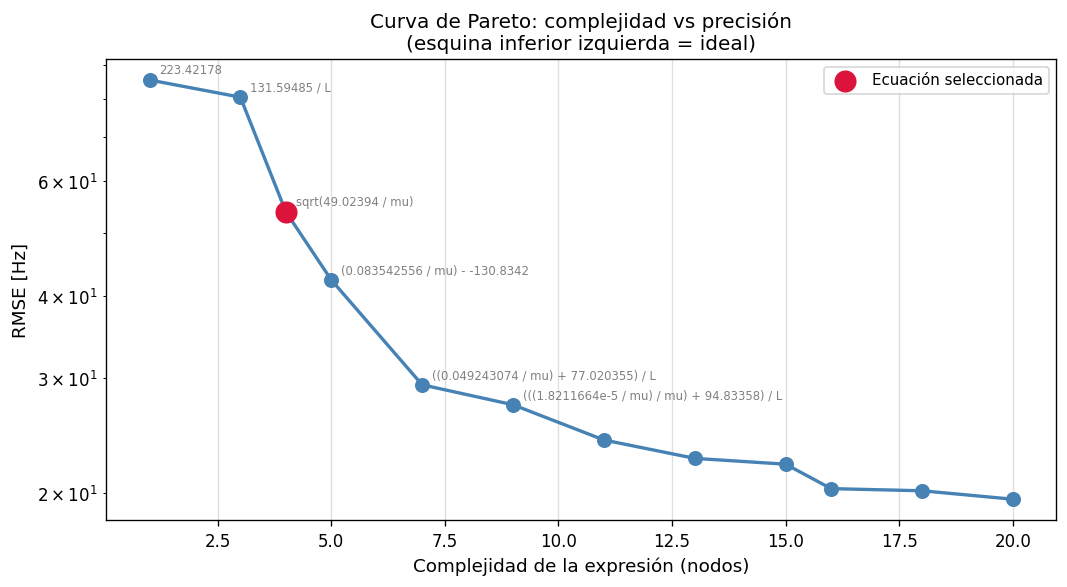

✅ Guardada 'pareto_pysr.png'


In [8]:
eqs = model.equations_.copy()
eqs['rmse'] = np.sqrt(eqs['loss'])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(eqs['complexity'], eqs['rmse'], 'o-', color='steelblue',
        markersize=8, lw=2)

# Resaltar la ecuación seleccionada
best_idx = model.equations_['score'].idxmax()
ax.scatter(eqs.loc[best_idx, 'complexity'], eqs.loc[best_idx, 'rmse'],
           color='crimson', s=150, zorder=5, label='Ecuación seleccionada')

# Anotar ecuaciones cortas
for i, row in eqs.iterrows():
    eq_str = str(row['equation'])
    if len(eq_str) < 45:
        ax.annotate(eq_str, (row['complexity'], row['rmse']),
                    textcoords='offset points', xytext=(6, 4),
                    fontsize=7, color='gray')

ax.set_xlabel('Complejidad de la expresión (nodos)')
ax.set_ylabel('RMSE [Hz]')
ax.set_title('Curva de Pareto: complejidad vs precisión\n(esquina inferior izquierda = ideal)')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.savefig('pareto_pysr.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardada 'pareto_pysr.png'")

---
## Celda 9 – Gráfica: f predicha vs f medida (paridad)

In [ ]:
f_pred = model.predict(X_df)
f_teo  = (1 / (2 * df['L_m'])) * np.sqrt(df['T_N'] / df['mu_kgm'])

# R² manual
ss_res = np.sum((y - f_pred)**2)
ss_tot = np.sum((y - y.mean())**2)
R2 = 1 - ss_res / ss_tot

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Comparación de modelos — f [Hz]', fontsize=13)

for ax_idx, (f_modelo, titulo, color) in enumerate([
    (f_pred, f'PySR — ecuación simbólica\n$R^2 = {R2:.5f}$', 'crimson'),
    (f_teo,  f'Modelo teórico $\\frac{{1}}{{2L}}\\sqrt{{T/\\mu}}$\n$R^2 = {1 - np.sum((y-f_teo.values)**2)/ss_tot:.5f}$', 'steelblue'),
]):
    ax = axes[ax_idx]
    ax.scatter(y, np.array(f_modelo), s=55, edgecolors='k', lw=0.4, color=color)
    lims = [y.min()*0.93, y.max()*1.05]
    ax.plot(lims, lims, 'k--', lw=1.5)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('f medida [Hz]'); ax.set_ylabel('f predicha [Hz]')
    ax.set_title(titulo)

plt.tight_layout()
plt.savefig('paridad_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Guardada paridad_comparacion.png')
print(f'   R² PySR:     {R2:.6f}')
print(f'   R² teórico:  {1 - np.sum((y-f_teo.values)**2)/ss_tot:.6f}')


---
## Celda 10 – Panel: f vs cada variable (T, μ, L) separada por cuerda

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Frecuencia vs variables físicas — datos experimentales', fontsize=13)

variables = [
    ('T_N',    'Tensión T [N]'),
    ('mu_kgm', 'Densidad lineal μ [kg/m]'),
    ('L_m',    'Longitud vibrante L [m]'),
]

for ax, (col, xlabel) in zip(axes, variables):
    sub = df.sort_values(col)
    ax.scatter(sub[col], sub['f_Hz'], s=55, edgecolors='k', lw=0.4,
               color='steelblue', zorder=4)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('f [Hz]')
    ax.set_title(f'f vs {xlabel.split(" ")[0]}')

plt.tight_layout()
plt.savefig('panel_f_vs_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardada 'panel_f_vs_variables.png'")


---
## Celda 11 – Ecuación final y comparación numérica

In [ ]:
print('=' * 65)
print('  RESUMEN FINAL')
print('=' * 65)
print()
print('  Ecuación teórica esperada:')
print('  f = (1 / (2·L)) · √(T / μ)')
print()
print('  Ecuación encontrada por PySR:')
print(f'  f = {model.sympy()}')
print()

df['f_pysr'] = f_pred
RMSE_teo  = np.sqrt(np.mean((df['f_Hz'] - df['f_teorica'])**2))
RMSE_pysr = np.sqrt(np.mean((df['f_Hz'] - df['f_pysr'])**2))
err_teo_pct  = (np.abs(df['f_Hz'] - df['f_teorica']) / df['f_Hz'] * 100).mean()
err_pysr_pct = (np.abs(df['f_Hz'] - df['f_pysr'])    / df['f_Hz'] * 100).mean()

print(f'  Filas evaluadas : {len(df)}')
print(f'  RMSE — Teórico  : {RMSE_teo:.4f} Hz  ({err_teo_pct:.2f}% error medio)')
print(f'  RMSE — PySR     : {RMSE_pysr:.4f} Hz  ({err_pysr_pct:.2f}% error medio)')


$$f = -28.534763 + \frac{4.343676}{\sqrt{\mu} \cdot (-16606.701 \cdot L \cdot \mu^2 + L)}$$

$$f = \frac{\sqrt{T/\mu}}{2L} = \frac{1}{2} \cdot L^{-1} \cdot T^{0.5} \cdot \mu^{-0.5}$$

---
## Celda 12 – Exportar resultados

In [ ]:
# Dataset con predicciones incluidas
df_out = df[['f_Hz', 'T_N', 'mu_kgm', 'L_m', 'f_teorica', 'f_pysr', 'error_pct']].copy()
df_out['err_pysr_pct'] = np.abs(df['f_Hz'] - df['f_pysr']) / df['f_Hz'] * 100
df_out.to_csv('resultados_regresion_simbolica.csv', index=False, float_format='%.6f')

# Tabla de ecuaciones de Pareto
model.equations_[['complexity', 'equation', 'loss', 'score']].to_csv(
    'ecuaciones_pareto.csv', index=True)

print('✅ Archivos exportados:')
print('   - resultados_regresion_simbolica.csv')
print('   - ecuaciones_pareto.csv')


---
## Notas sobre la interpretación

### ¿Qué esperar de PySR?

Si los datos son consistentes con la física, PySR debería encontrar algo equivalente a:

$$f = \frac{\sqrt{T/\mu}}{2L} = \frac{1}{2} \cdot L^{-1} \cdot T^{0.5} \cdot \mu^{-0.5}$$

Puede aparecer en formas algebráicamente equivalentes como `sqrt(T/mu) / (2*L)` o `0.5 * sqrt(T) / (L * sqrt(mu))`.

### Curva de Pareto
La gráfica de Pareto muestra el **balance complejidad–precisión**. La ecuación óptima está en el "codo" de esa curva — donde agregar más complejidad ya no mejora significativamente el error.

### Fuentes de desviación
- Las cuerdas reales tienen **rigidez de flexión** (stiffness), que desplaza ligeramente las frecuencias respecto al modelo ideal.
- Los valores de $\mu$ tomados de internet pueden diferir de los valores reales de tus cuerdas.
- El ángulo de la clavija es una medida indirecta de $T$: cualquier error en la calibración de $T$ se propaga.